# Sensitivity to multispreader activity

Our model has been calibrated to handle alph=3, but hte researchers sait this is the parameter that impacts outcome most, so we will see it in our implementation it is also very impactful.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import infection_model as model

# ==========================================
# 1. CONFIGURATION
# ==========================================
ALPHA_RANGE = np.arange(1, 7)  # 1 to 6
REPETITIONS = 100
DAYS = 60
N_AGENTS = 5000
INIT_NORMAL = 2
INIT_MULTI = 1
SPREAD_THRESHOLD = 50 # Lowered slightly for lower alpha values

# ==========================================
# 2. SIMULATION PHASE
# ==========================================
print(f"--- Alpha Sensitivity Sweep (N={N_AGENTS}, Reps={REPETITIONS}) ---")
start_time_total = time.time()

all_results = []

for alpha_val in ALPHA_RANGE:
    print(f"Simulating Alpha={alpha_val}...", end="", flush=True)
    loop_start = time.time()
    
    for r in range(REPETITIONS):
        params = model.Params(
            T=DAYS * 24,
            N=N_AGENTS,
            alpha=alpha_val, # The variable being tested
            initial_infected_normal=INIT_NORMAL,
            initial_infected_multispreader=INIT_MULTI,
            ratios=model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
            schools=4,
            primary_care=20,
            hospitals=1,
            other_working_places=100,
            public_places=50
        )
        
        sim = model.Simulation(params=params)
        sim.init()
        sim.run(dt=12.0)
        
        stats = sim.get_stats_df()
        df = pd.DataFrame(stats)
        
        # Calculate Peak and Time for this specific run
        i_total = df["I0"] + df["I1"] + df["I2"]
        peak_inf = i_total.max()
        peak_day = df.loc[i_total.idxmax(), "time"] / 24.0
        
        # We only record the summary for analysis to keep the CSV manageable
        all_results.append({
            "alpha": alpha_val,
            "run_id": r,
            "peak_infections": peak_inf,
            "peak_time": peak_day,
            "success": 1 if peak_inf > SPREAD_THRESHOLD else 0
        })
        
    print(f" Done ({time.time() - loop_start:.2f}s)")

# ==========================================
# 3. SAVE DATA
# ==========================================
sensitivity_df = pd.DataFrame(all_results)
filename = f"alpha_sensitivity_N{N_AGENTS}_R{REPETITIONS}.csv"
sensitivity_df.to_csv(filename, index=False)
print(f"\n[Saved] Results to: {filename}")

--- Alpha Sensitivity Sweep (N=5000, Reps=100) ---
Simulating Alpha=1... Done (2456.51s)
Simulating Alpha=2... Done (2565.57s)
Simulating Alpha=3... Done (2120.19s)
Simulating Alpha=4... Done (1909.75s)
Simulating Alpha=5... Done (2019.82s)
Simulating Alpha=6... Done (2402.24s)

[Saved] Results to: alpha_sensitivity_N5000_R100.csv


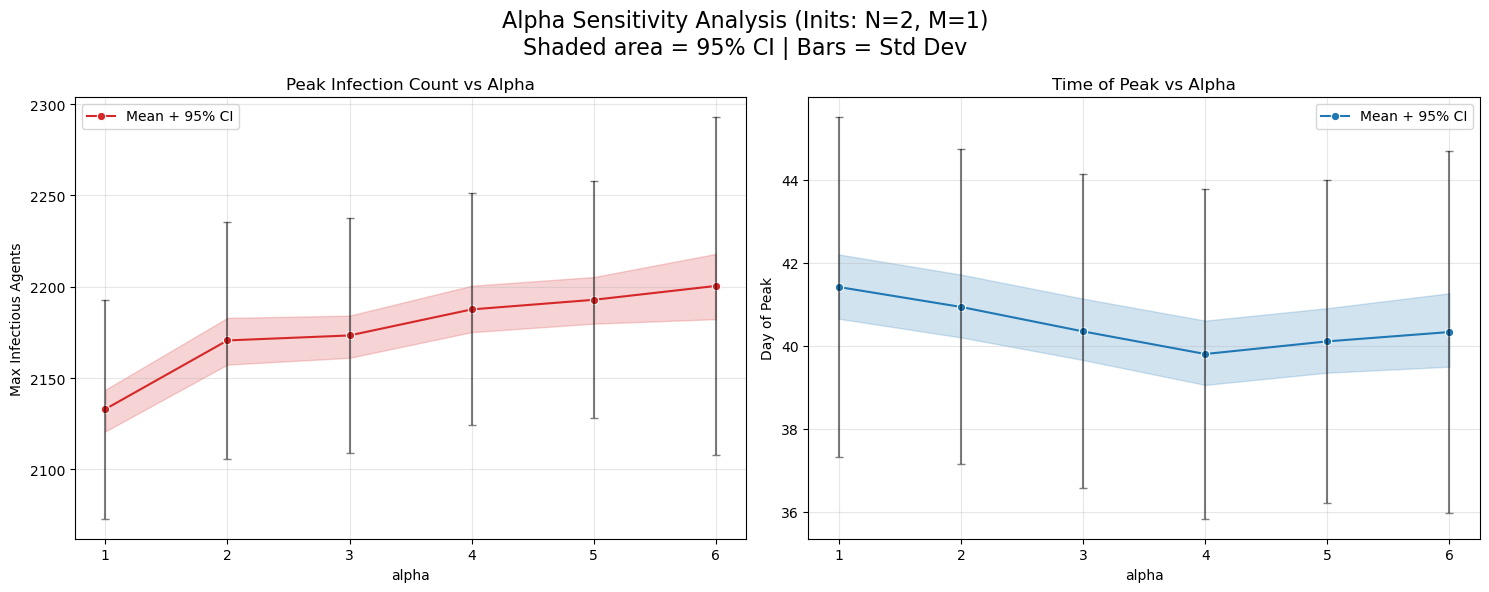


--- Summary Statistics (Survivors Only) ---
      peak_infections            peak_time          
                 mean        std      mean       std
alpha                                               
1             2133.04  59.949797    41.415  4.100416
2             2170.63  64.715797    40.935  3.797697
3             2173.35  64.158323    40.345  3.787069
4             2187.60  63.485622    39.800  3.970217
5             2192.86  64.845273    40.105  3.895928
6             2200.45  92.452486    40.330  4.359606


In [2]:
# ==========================================
# 4. LOAD & ANALYZE
# ==========================================
# Reloading as requested to ensure analysis is file-based
data = pd.read_csv(filename)

# Filter for "Successful" outbreaks to avoid skewing means with zeros
analysis_data = data[data["success"] == 1].copy()

# Setup Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Alpha Sensitivity Analysis (Inits: N={INIT_NORMAL}, M={INIT_MULTI})\nShaded area = 95% CI | Bars = Std Dev", fontsize=16)

# Plot A: Peak Infections
sns.lineplot(data=analysis_data, x="alpha", y="peak_infections", ax=axes[0], 
             marker='o', errorbar=('ci', 95), label='Mean + 95% CI', color='tab:red')
# Adding STD as a separate visualization
for alpha in ALPHA_RANGE:
    subset = analysis_data[analysis_data["alpha"] == alpha]
    if not subset.empty:
        mean = subset["peak_infections"].mean()
        std = subset["peak_infections"].std()
        axes[0].errorbar(alpha, mean, yerr=std, fmt='none', color='black', capsize=3, alpha=0.5)

axes[0].set_title("Peak Infection Count vs Alpha")
axes[0].set_ylabel("Max Infectious Agents")
axes[0].grid(True, alpha=0.3)

# Plot B: Time of Peak
sns.lineplot(data=analysis_data, x="alpha", y="peak_time", ax=axes[1], 
             marker='o', errorbar=('ci', 95), label='Mean + 95% CI', color='tab:blue')
# Adding STD
for alpha in ALPHA_RANGE:
    subset = analysis_data[analysis_data["alpha"] == alpha]
    if not subset.empty:
        mean = subset["peak_time"].mean()
        std = subset["peak_time"].std()
        axes[1].errorbar(alpha, mean, yerr=std, fmt='none', color='black', capsize=3, alpha=0.5)

axes[1].set_title("Time of Peak vs Alpha")
axes[1].set_ylabel("Day of Peak")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print("\n--- Summary Statistics (Survivors Only) ---")
summary = analysis_data.groupby("alpha")[["peak_infections", "peak_time"]].agg(["mean", "std"])
print(summary)